# Minimum Risk Portfolios — CRSP Backtest

Builds fully-invested, long-only **minimum risk** portfolios on the CRSP universe and
compares them out of sample against the two ad-hoc benchmarks required by the project:
a **value (capitalization) weighted** and an **equally weighted** portfolio over the
same universe.

Covariance comes from the **single-factor model** of Homework 3, so the minimum-risk
problem has the analytic solution of Homework 4, Exercise 2.

Section headings below map to the implementation steps on page 2 of `project.pdf`.

| Step | Where |
|---|---|
| (a) choose test period, `T`, `n` | §3 |
| (b) estimate at the start date, record the next month | §4 |
| (c) repeat to the end date | §5 |
| (d) summary statistics and cumulative return charts | §6, §7 |

## 1. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estimation import estimate_single_factor
from portfolios import min_risk, min_risk_closed_form, equal_weight, value_weight
from backtest import select_universe, rolling_backtest, summarize

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

python 3.13.9 | numpy 2.3.5 | pandas 2.3.3


## 2. Load and validate the data

Two inputs:

* `data/crsp_msf_v2.parquet` — CRSP monthly stock file, 1990-01 to 2025-12.
* `data/MktRf.csv` — market excess return and risk-free rate from Kenneth French.

Two things to be careful about.

**Units.** CRSP returns are decimals; French's data is in *percentage points*, so
`Mkt-RF` and `RF` are divided by 100. `project.pdf` flags this explicitly on page 1.

**Date keys.** `mthcaldt` is the last *trading* day of the month, not the last calendar
day (1994-12-31 fell on a Saturday, so the record is dated 1994-12-30). Everything is
therefore keyed on the integer `yyyymm`, which joins cleanly with French's data.

In [2]:
crsp = pd.read_parquet(
    "data/crsp_msf_v2.parquet",
    columns=["permno", "yyyymm", "mthret", "mthcap", "primaryexch", "mthdelflg"],
)
print(f"CRSP: {len(crsp):,} rows, {crsp.yyyymm.min()}-{crsp.yyyymm.max()}, "
      f"{crsp.permno.nunique():,} permno")

ff = pd.read_csv("data/MktRf.csv", index_col=0)
ff.index.name = "yyyymm"
mkt_all = ff["Mkt-RF"] / 100.0      # percentage points -> decimals
rf_all = ff["RF"] / 100.0
print(f"MktRf: {ff.index.min()}-{ff.index.max()}")

CRSP: 2,179,752 rows, 199001-202512, 18,905 permno
MktRf: 192607-202607


### Exchange filter

This extract carries `primaryexch` but **not** `sharetype` / `securitytype`, so the
standard CRSP CIZ common-share filter cannot be applied. We keep NYSE / NYSE American /
Nasdaq (`N`, `A`, `Q`) and drop the rest. This leaves some non-common securities in the
universe; worth stating as a limitation rather than papering over.

In [3]:
KEEP_EXCH = ["N", "A", "Q"]
before = len(crsp)
crsp = crsp[crsp.primaryexch.isin(KEEP_EXCH)]
print(f"exchange filter: dropped {before - len(crsp):,} of {before:,} rows "
      f"({(before - len(crsp)) / before:.2%})")
print("\ndelisting flags retained in the filtered sample:")
print(crsp.mthdelflg.value_counts().to_string())

exchange filter: dropped 39,166 of 2,179,752 rows (1.80%)

delisting flags retained in the filtered sample:


mthdelflg
N    2125480
A       9015
P       5119
M        798
V        114
G         60


### Reshape into panels

`rets` and `caps` are month x permno. `mthret` already includes the delisting return in
CRSP v2, so no separate merge is needed.

In [4]:
rets = crsp.pivot_table(index="yyyymm", columns="permno", values="mthret")
caps = crsp.pivot_table(index="yyyymm", columns="permno", values="mthcap")
mkt = mkt_all.reindex(rets.index)
rf = rf_all.reindex(rets.index)

print(f"panel: {rets.shape[0]} months x {rets.shape[1]:,} stocks")
assert not mkt.isna().any() and not rf.isna().any(), "MktRf does not cover the CRSP window"
assert rets.index.equals(caps.index) and rets.index.equals(mkt.index)
print("market and risk-free aligned, no gaps")

panel: 432 months x 18,898 stocks
market and risk-free aligned, no gaps


### Unit checks

The single most common failure in this pipeline is forgetting to divide French's data by
100. Monthly market volatility should be roughly 4-5%; if it comes out near 4-5 (i.e.
400-500%), the division was missed.

In [5]:
sigma_M_monthly = mkt.std()
print(f"monthly sigma of Mkt-RF        = {sigma_M_monthly:.4f}   (expect 0.04-0.05)")
print(f"mean monthly RF                = {rf.mean():.4f}   (expect ~0.002-0.004)")
print(f"mthret range                   = [{rets.min().min():.2f}, {rets.max().max():.2f}]")

assert 0.03 < sigma_M_monthly < 0.07, "Mkt-RF units look wrong -- did you divide by 100?"
assert 0.0 <= rf.mean() < 0.01, "RF units look wrong"
assert rets.min().min() >= -1.0, "a return below -100% is impossible"
print("\nunit checks passed")

monthly sigma of Mkt-RF        = 0.0439   (expect 0.04-0.05)
mean monthly RF                = 0.0022   (expect ~0.002-0.004)
mthret range                   = [-1.00, 26.58]

unit checks passed


## 3. Parameters — satisfies step (a)

> *"Select some test period (startYear, endYear), length T of in-sample data history for
> estimation purposes, and size n of the investment universe. Some reasonable choices are
> startYear = 1995, endYear = 2025, T = 60 months, and n = 500 stocks."*

We use exactly those values. With data starting in 1990-01 and `T = 60`, the first
estimation window is 1990-01..1994-12, so the first out-of-sample month is 1995-01 — the
suggested start date falls out of the data rather than being imposed.

In [6]:
START_YEAR, END_YEAR = 1995, 2025
T = 60      # months of in-sample history used for estimation
N = 500     # stocks in the investment universe

idx = rets.index
first_oos = START_YEAR * 100 + 1          # 199501
last_oos = END_YEAR * 100 + 12            # 202512
i_first = idx.get_loc(first_oos) - 1      # last in-sample month before the first OOS month
i_last = idx.get_loc(last_oos) - 1

n_oos = i_last - i_first + 1
print(f"estimation window length T = {T} months, universe size n = {N}")
print(f"first rebalance at {idx[i_first]} -> first out-of-sample month {idx[i_first+1]}")
print(f"last  rebalance at {idx[i_last]} -> last  out-of-sample month {idx[i_last+1]}")
print(f"out-of-sample months = {n_oos}")

assert i_first >= T - 1, "not enough history for the first estimation window"
assert n_oos == 372, f"expected 372 out-of-sample months, got {n_oos}"

estimation window length T = 60 months, universe size n = 500
first rebalance at 199412 -> first out-of-sample month 199501
last  rebalance at 202511 -> last  out-of-sample month 202512
out-of-sample months = 372


## 4. One rebalance, step by step — satisfies step (b)

> *"At the start date estimate the parameters of your models based on the previous T
> months and compute the relevant portfolios. Then observe and record the performance of
> these portfolios over the next month."*

Walking through the very first rebalance date in full. Everything here uses only
information available at that date.

In [7]:
t = idx[i_first]                 # 199412 -- the last in-sample month
t_next = idx[i_first + 1]        # 199501 -- the first out-of-sample month
window = idx[i_first - T + 1 : i_first + 1]
print(f"estimation window: {window[0]}..{window[-1]}  ({len(window)} months)")
print(f"portfolio held during: {t_next}")

universe = select_universe(rets, caps, window, t, N)
print(f"\nuniverse: {len(universe)} stocks, largest by market cap at {t} "
      f"with a complete {T}-month return history")

estimation window: 199001..199412  (60 months)
portfolio held during: 199501

universe: 500 stocks, largest by market cap at 199412 with a complete 60-month return history


### Estimate the single-factor model

Excess returns on both sides, intercept retained. This is the *market model*, a
statistical description of the covariance structure, not the CAPM — so alpha is not
forced to zero.

In [8]:
R = rets.loc[window, universe].values - rf.loc[window].values[:, None]
cov = estimate_single_factor(R, mkt.loc[window].values, permno=universe.values)

print(f"sigma_M (monthly) = {np.sqrt(cov.sigmaM2):.4f}")
print(f"beta   : mean {cov.beta.mean():.3f}, range [{cov.beta.min():.2f}, {cov.beta.max():.2f}]")
print(f"beta_hat (pre-shrinkage) range [{cov.beta_hat.min():.2f}, {cov.beta_hat.max():.2f}]")
print(f"residual vol (monthly): mean {np.sqrt(cov.omega2).mean():.4f}")
print("\nBlume shrinkage pulls the cross-sectional spread of beta in:")
print(f"  std(beta_hat) = {cov.beta_hat.std():.4f} -> std(beta) = {cov.beta.std():.4f}")

sigma_M (monthly) = 0.0371
beta   : mean 1.088, range [0.28, 2.29]
beta_hat (pre-shrinkage) range [-0.08, 2.93]
residual vol (monthly): mean 0.0692

Blume shrinkage pulls the cross-sectional spread of beta in:
  std(beta_hat) = 0.4837 -> std(beta) = 0.3224


### Build the portfolio, two ways

Homework 4 Exercise 2(a) asks for a cvxpy model and a numerical check against the
analytic solution

$$x_i = \frac{\sigma^2_{LMV}}{\omega_i^2}\left(1 - \frac{\beta_i}{\beta_{LO}}\right)^+$$

Only stocks with beta below the threshold $\beta_{LO}$ are held, so the entire solution
is pinned down by that one scalar. Both routes are run here and compared.

The right test of agreement is the **objective value**, not elementwise weights. This is a
strictly convex problem, so a lower variance means a better solution; and an interior-point
solver leaves small residual weights on names sitting right at the threshold rather than
driving them to exactly zero. The closed form is exact, so it should win by a hair.

In [9]:
import time

t0 = time.time(); res_cf = min_risk_closed_form(cov); dt_cf = time.time() - t0
t0 = time.time(); res_cp = min_risk(cov);              dt_cp = time.time() - t0

print(f"closed form : {dt_cf*1000:7.2f} ms   variance {res_cf['sigma2']:.8f}   "
      f"{res_cf['n_held']} holdings")
print(f"cvxpy       : {dt_cp*1000:7.2f} ms   variance {res_cp['sigma2']:.8f}   "
      f"{res_cp['n_held']} holdings")
rel_gap = (res_cp["sigma2"] - res_cf["sigma2"]) / res_cf["sigma2"]
dw = np.abs(res_cf["x"] - res_cp["x"])
print(f"\nobjective: cvxpy is {rel_gap:+.2e} relative to the closed form")
print(f"weights  : max diff {dw.max():.2e} ({dw.max()/res_cf['x'].max():.2%} of the "
      f"largest holding), mean diff {dw.mean():.2e}")
print(f"speedup  : {dt_cp/dt_cf:,.0f}x")

# The objective is the meaningful criterion for a strictly convex problem.
assert abs(rel_gap) < 1e-4, "the two solvers reach materially different objectives"
assert rel_gap >= -1e-9, "cvxpy beat the exact solution -- the closed form has a bug"
assert dw.mean() < 1e-4, "weights differ by more than solver tolerance"

# Where they differ: names sitting essentially on the threshold.
edge = (res_cp["x"] > 0) & (res_cf["x"] == 0)
if edge.any():
    print(f"\ncvxpy leaves dust on {edge.sum()} names the closed form excludes "
          f"(total weight {res_cp['x'][edge].sum():.1e});")
    print(f"their betas are {cov.beta[edge].min():.4f}..{cov.beta[edge].max():.4f}, "
          f"just above beta_LO = {res_cf['beta_LO']:.4f}")
print("\nthe two agree on the solution; the closed form is exact and is used from here on")

closed form :    0.23 ms   variance 0.00046475   42 holdings
cvxpy       :  706.68 ms   variance 0.00046475   45 holdings

objective: cvxpy is +1.72e-06 relative to the closed form
weights  : max diff 1.66e-04 (0.20% of the largest holding), mean diff 1.01e-06
speedup  : 3,034x

cvxpy leaves dust on 3 names the closed form excludes (total weight 2.3e-04);
their betas are 0.6458..0.6504, just above beta_LO = 0.6448

the two agree on the solution; the closed form is exact and is used from here on


### The threshold structure

Minimum risk is, under a single-factor covariance, a **low-beta bet**: it holds a stock
only if its beta sits below $\beta_{LO}$, and weights it by $1/\omega_i^2$ within that
set. The plot below shows where the cut falls.

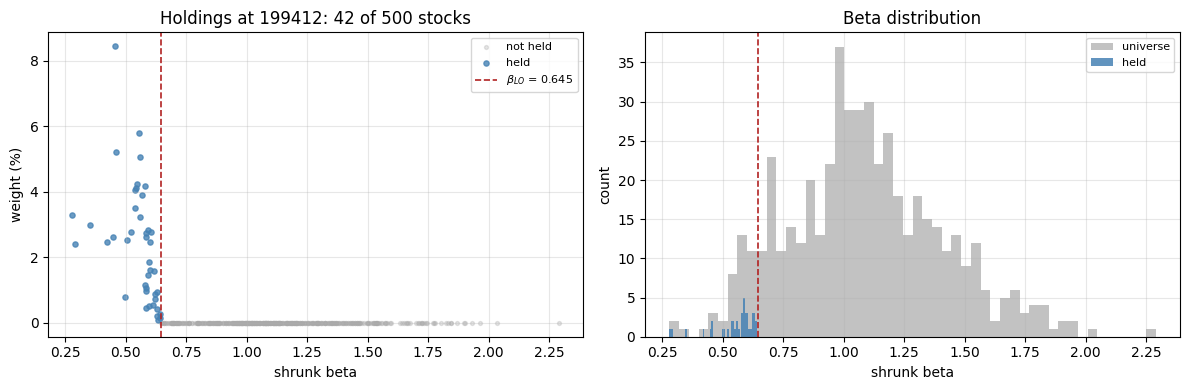

portfolio beta  = 0.523   (universe mean 1.088)
predicted vol   = 0.0747 annualised
largest holding = 8.45%


In [10]:
x_cf = res_cf["x"]
beta_LO = res_cf["beta_LO"]
held = x_cf > 0

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(cov.beta[~held], np.zeros((~held).sum()), s=8, alpha=0.3,
              color="darkgrey", label="not held")
ax[0].scatter(cov.beta[held], x_cf[held] * 100, s=14, alpha=0.8,
              color="steelblue", label="held")
ax[0].axvline(beta_LO, color="firebrick", ls="--", lw=1.2,
              label=f"$\\beta_{{LO}}$ = {beta_LO:.3f}")
ax[0].set_xlabel("shrunk beta"); ax[0].set_ylabel("weight (%)")
ax[0].set_title(f"Holdings at {t}: {held.sum()} of {len(universe)} stocks")
ax[0].legend(fontsize=8)

ax[1].hist(cov.beta, bins=50, color="darkgrey", alpha=0.7, label="universe")
ax[1].hist(cov.beta[held], bins=50, color="steelblue", alpha=0.85, label="held")
ax[1].axvline(beta_LO, color="firebrick", ls="--", lw=1.2)
ax[1].set_xlabel("shrunk beta"); ax[1].set_ylabel("count")
ax[1].set_title("Beta distribution"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"portfolio beta  = {cov.exante_beta(x_cf):.3f}   (universe mean {cov.beta.mean():.3f})")
print(f"predicted vol   = {cov.exante_vol(x_cf)*np.sqrt(12):.4f} annualised")
print(f"largest holding = {x_cf.max():.2%}")

### Record the out-of-sample month

In [11]:
r_next = rets.loc[t_next, universe]
missing = r_next.isna().sum()
r_next = r_next.fillna(float(rf.loc[t_next])).values

print(f"holdings with no return in {t_next}: {missing} "
      f"(their weight is assumed to earn the risk-free rate)")
for name, w in [("min risk", x_cf),
                ("equally weighted", equal_weight(cov)["x"]),
                ("value weighted", value_weight(cov, caps=caps.loc[t, universe].values)["x"])]:
    print(f"  {name:18s} {t_next} return = {float(w @ r_next):+.4%}")

holdings with no return in 199501: 0 (their weight is assumed to earn the risk-free rate)
  min risk           199501 return = +4.1668%
  equally weighted   199501 return = +2.6204%
  value weighted     199501 return = +2.8339%


## 5. Full rolling backtest — satisfies step (c)

> *"In principle it would be sensible to estimate parameters and compute portfolios every
> month. However, you may choose to do it less frequently depending on your time
> constraints... This is a judgement call you will need to make."*

**We rebalance monthly.** The escape clause in the project is conditioned on time
constraints, and the analytic solution removes that constraint: the measured speedup
above makes the full 372-month backtest run in about a second, so there is no reason to
rebalance less often.

Two accounting decisions worth stating:

* **Delisting.** A holding with no return in month `t+1` has its weight earn the
  risk-free rate. Renormalising over the survivors instead would amount to knowing at the
  start of the month which stocks were about to disappear.
* **Turnover** is measured against the *drifted* weights of the previous month, so
  passive drift is not counted as trading.

In [12]:
t0 = time.time()
panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last])
print(f"backtest finished in {time.time() - t0:.1f}s")
print(f"{panel.index.get_level_values('date').nunique()} out-of-sample months x "
      f"{panel.index.get_level_values('strategy').nunique()} strategies")
panel.head(6)

backtest finished in 1.8s
372 out-of-sample months x 3 strategies


ret  exret  pred_vol  exante_beta  n_held  beta_LO    eff_n  max_w  turnover
date   strategy                                                                                
199501 ew       0.0262 0.0220    0.0405       1.0880     500      NaN 500.0000 0.0020       NaN
       min_risk 0.0417 0.0375    0.0216       0.5230      42   0.6448  26.9241 0.0845       NaN
       vw       0.0283 0.0241    0.0385       1.0310     500      NaN 161.5817 0.0258       NaN
199502 ew       0.0444 0.0404    0.0389       1.0909     500      NaN 500.0000 0.0020    0.0476
       min_risk 0.0261 0.0221    0.0205       0.5173      43   0.6423  26.4737 0.0890    0.1389
       vw       0.0384 0.0344    0.0370       1.0340     500      NaN 163.0090 0.0253    0.0096

### Correctness checks

In [13]:
n_months = panel.index.get_level_values("date").nunique()
assert n_months == 372, f"expected 372 months, got {n_months}"

for name, w in weights.items():
    assert np.allclose(w.sum(axis=1), 1.0), f"{name}: weights do not sum to 1"
    assert (w.fillna(0) >= -1e-12).all().all(), f"{name}: negative weight found"

# The equally weighted return must equal the plain cross-sectional mean of the universe.
d0 = weights["ew"].index[0]
uni0 = weights["ew"].loc[d0].dropna().index
nxt0 = idx[idx.get_loc(d0) + 1]
assert np.isclose(panel.loc[(nxt0, "ew"), "ret"], rets.loc[nxt0, uni0].mean())

# Out-of-sample returns must be untouched.
assert rets.max().max() > 20, "raw returns appear to have been modified"

print("all checks passed:")
print(f"  372 out-of-sample months")
print(f"  weights sum to 1 and are non-negative for all strategies")
print(f"  EW return reproduces the cross-sectional mean")
print(f"  out-of-sample returns were not winsorised or clipped")

all checks passed:
  372 out-of-sample months
  weights sum to 1 and are non-negative for all strategies
  EW return reproduces the cross-sectional mean
  out-of-sample returns were not winsorised or clipped


## 6. Summary statistics — satisfies step (d)

Sharpe ratios use excess returns; annualised return is geometric.
`pred_over_realized` divides the average predicted volatility by the realised one, and is
the diagnostic that says whether the covariance model knew what it was doing.

In [14]:
summary = summarize(panel)
summary.index = ["equally weighted", "minimum risk", "value weighted"]
summary = summary.loc[["minimum risk", "value weighted", "equally weighted"]]
summary.round(4)

,ann_return,ann_vol,sharpe,max_drawdown,pred_over_realized,avg_n_held,avg_eff_n,ann_turnover
minimum risk,0.0820,0.1272,0.4992,-0.3755,0.5741,45.1156,25.3440,1.1662
value weighted,0.1155,0.1482,0.6557,-0.4913,1.0015,500.0000,112.2817,0.1001
equally weighted,0.1163,0.1574,0.6313,-0.5170,0.9682,500.0000,500.0000,0.6166


In [15]:
mr, ew, vw = summary.loc["minimum risk"], summary.loc["equally weighted"], summary.loc["value weighted"]
print(f"minimum risk cuts annualised volatility to {mr.ann_vol:.2%}, against "
      f"{ew.ann_vol:.2%} for EW and {vw.ann_vol:.2%} for VW")
print(f"  that is a {1 - mr.ann_vol/vw.ann_vol:.1%} reduction versus the cap-weighted benchmark")
print(f"\nit does so holding {mr.avg_n_held:.0f} of {N} stocks on average, "
      f"at an average beta of {panel.xs('min_risk', level='strategy').exante_beta.mean():.2f}")
print(f"\nSharpe:  min risk {mr.sharpe:.3f} | VW {vw.sharpe:.3f} | EW {ew.sharpe:.3f}")
assert mr.ann_vol < ew.ann_vol and mr.ann_vol < vw.ann_vol, \
    "minimum risk failed to deliver the lowest realised volatility"

minimum risk cuts annualised volatility to 12.72%, against 15.74% for EW and 14.82% for VW
  that is a 14.2% reduction versus the cap-weighted benchmark

it does so holding 45 of 500 stocks on average, at an average beta of 0.43

Sharpe:  min risk 0.499 | VW 0.656 | EW 0.631


## 7. Cumulative return charts — satisfies step (d)

Two views. The left panel is the cumulative *sum* of excess returns: additive cumulation
is easier to read and makes a more sensible comparison across strategies than compounding,
which visually rewards whichever line happens to be the most volatile. The right panel
plots each strategy against the value-weighted benchmark, which is where the regime story
lives — levels are already in the table above, the path is not.

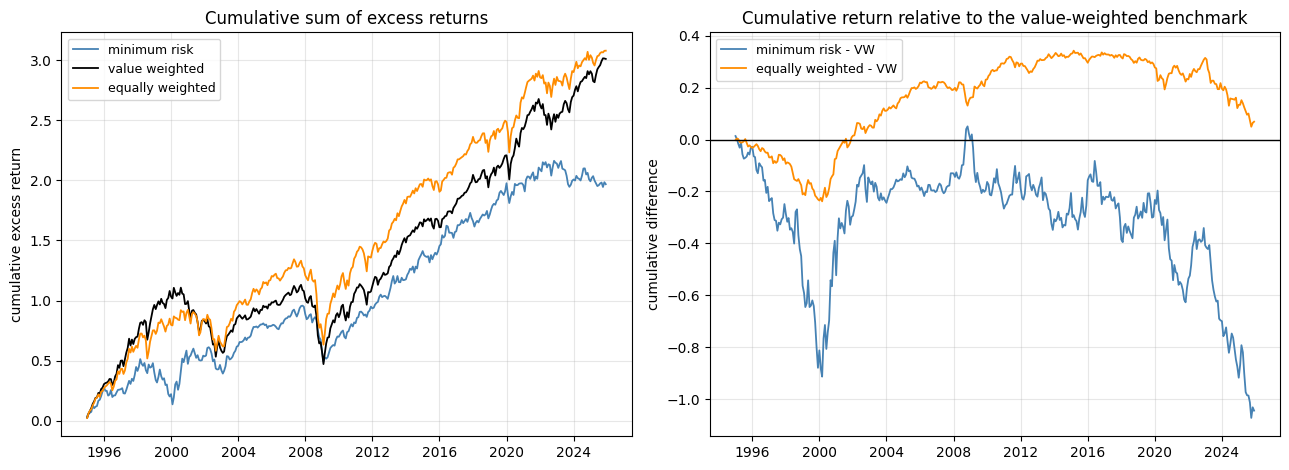

In [16]:
wide = panel.exret.unstack("strategy")
labels = {"min_risk": "minimum risk", "vw": "value weighted", "ew": "equally weighted"}
colors = {"min_risk": "steelblue", "vw": "black", "ew": "darkorange"}
periods = pd.PeriodIndex([str(d) for d in wide.index], freq="M").to_timestamp()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for s in ["min_risk", "vw", "ew"]:
    ax[0].plot(periods, wide[s].cumsum(), label=labels[s], color=colors[s], lw=1.3)
ax[0].set_title("Cumulative sum of excess returns")
ax[0].set_ylabel("cumulative excess return"); ax[0].legend(fontsize=9)

for s in ["min_risk", "ew"]:
    ax[1].plot(periods, (wide[s] - wide["vw"]).cumsum(), label=f"{labels[s]} - VW",
               color=colors[s], lw=1.3)
ax[1].axhline(0, color="black", lw=1)
ax[1].set_title("Cumulative return relative to the value-weighted benchmark")
ax[1].set_ylabel("cumulative difference"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 8. Subperiods — satisfies the step (a) suggestion

> *"You may want to report results for different test periods that span different kinds of
> economic conditions."*

Decade buckets first, then the specific episodes. The episodes matter: a bucket running
1995-2007 would contain both the late-1990s bull market, where minimum risk lags badly,
and the 2000-2002 bust, where it does best — averaging the two hides the whole effect.

Episode returns are reported **cumulatively** rather than annualised, because a couple of
these windows are only two months long and annualising them yields figures that look
dramatic but carry no information.

In [17]:
def stats_for(panel, lo, hi, label):
    dates = panel.index.get_level_values("date")
    sub = panel[(dates >= lo) & (dates <= hi)]
    out = {}
    for s, g in sub.groupby(level="strategy"):
        vol = g.exret.std(ddof=1) * np.sqrt(12)
        out[labels[s]] = dict(
            ann_ret=(1 + g.ret.values).prod() ** (12 / len(g)) - 1,
            ann_vol=vol,
            sharpe=g.exret.mean() * 12 / vol,
        )
    return pd.concat({label: pd.DataFrame(out).T}, names=["period", "strategy"])

decades = [(199501, 199912, "1995-1999"), (200001, 200912, "2000-2009"),
           (201001, 201912, "2010-2019"), (202001, 202512, "2020-2025")]
pd.concat([stats_for(panel, lo, hi, lab) for lo, hi, lab in decades]).round(4)

ann_ret  ann_vol  sharpe
period    strategy                                  
1995-1999 equally weighted   0.2316   0.1395  1.2173
          minimum risk       0.0848   0.1308  0.3070
          value weighted     0.2885   0.1396  1.5466
2000-2009 equally weighted   0.0408   0.1701  0.1621
          minimum risk       0.0702   0.1340  0.3726
          value weighted    -0.0033   0.1545 -0.1196
2010-2019 equally weighted   0.1420   0.1344  1.0221
          minimum risk       0.1275   0.1052  1.1493
          value weighted     0.1366   0.1242  1.0566
2020-2025 equally weighted   0.1127   0.1825  0.5323
          minimum risk       0.0267   0.1448  0.0688
          value weighted     0.1565   0.1719  0.7808

In [18]:
# Cumulative, not annualised: some of these windows are only a couple of months,
# and annualising them produces numbers that look dramatic but mean nothing.
def episode_stats(panel, lo, hi, label):
    dates = panel.index.get_level_values("date")
    sub = panel[(dates >= lo) & (dates <= hi)]
    out = {}
    for s, g in sub.groupby(level="strategy"):
        out[labels[s]] = dict(
            months=len(g),
            cum_ret=(1 + g.ret.values).prod() - 1,
            vs_vw=(1 + g.ret.values).prod()
                  - (1 + sub.xs("vw", level="strategy").ret.values).prod(),
            ann_vol=g.exret.std(ddof=1) * np.sqrt(12),
        )
    return pd.concat({label: pd.DataFrame(out).T}, names=["period", "strategy"])

episodes = [(200003, 200209, "dot-com bust 2000-02"), (200711, 200902, "GFC 2007-09"),
            (202002, 202003, "COVID crash 2020"),     (202201, 202212, "2022 drawdown")]
pd.concat([episode_stats(panel, lo, hi, lab) for lo, hi, lab in episodes]).round(4)

months  cum_ret   vs_vw  ann_vol
period               strategy                                          
dot-com bust 2000-02 equally weighted 31.0000  -0.1450  0.2033   0.1859
                     minimum risk     31.0000   0.4211  0.7694   0.1865
                     value weighted   31.0000  -0.3483  0.0000   0.1754
GFC 2007-09          equally weighted 16.0000  -0.5170 -0.0256   0.2245
                     minimum risk     16.0000  -0.3709  0.1204   0.1507
                     value weighted   16.0000  -0.4913  0.0000   0.1868
COVID crash 2020     equally weighted  2.0000  -0.2368 -0.0475   0.2057
                     minimum risk      2.0000  -0.1560  0.0332   0.0682
                     value weighted    2.0000  -0.1893  0.0000   0.0953
2022 drawdown        equally weighted 12.0000  -0.1193  0.0633   0.2277
                     minimum risk     12.0000   0.0429  0.2255   0.1664
                     value weighted   12.0000  -0.1826  0.0000   0.2287

## 9. Diagnostics

### Predicted versus realised volatility

This is the sharpest result in the notebook, and it is a negative one.

The single-factor model assumes idiosyncratic residuals are **uncorrelated**. For broad
portfolios that is a tolerable approximation. For minimum risk it is not: the optimiser
concentrates into a few dozen low-beta names, which are heavily clustered in a handful of
defensive sectors, and their residuals move together. The model therefore understates the
risk of precisely the portfolio it was used to build.

The asymmetry is what makes the diagnosis safe — a mistake in scaling or annualisation
would bias all three portfolios by the same factor.

In [19]:
diag = pd.DataFrame({
    "predicted vol (ann.)": panel.pred_vol.groupby(level="strategy").mean() * np.sqrt(12),
    "realised vol (ann.)": panel.exret.groupby(level="strategy").std(ddof=1) * np.sqrt(12),
})
diag["ratio"] = diag.iloc[:, 0] / diag.iloc[:, 1]
diag.index = [labels[s] for s in diag.index]
print(diag.round(4).to_string())
print(f"\nthe model captures {diag.loc['minimum risk', 'ratio']:.0%} of minimum risk's "
      f"realised volatility, versus {diag.loc['equally weighted', 'ratio']:.0%} for EW "
      f"and {diag.loc['value weighted', 'ratio']:.0%} for VW")

                  predicted vol (ann.)  realised vol (ann.)  ratio
equally weighted                0.1524               0.1574 0.9682
minimum risk                    0.0730               0.1272 0.5741
value weighted                  0.1484               0.1482 1.0015

the model captures 57% of minimum risk's realised volatility, versus 97% for EW and 100% for VW


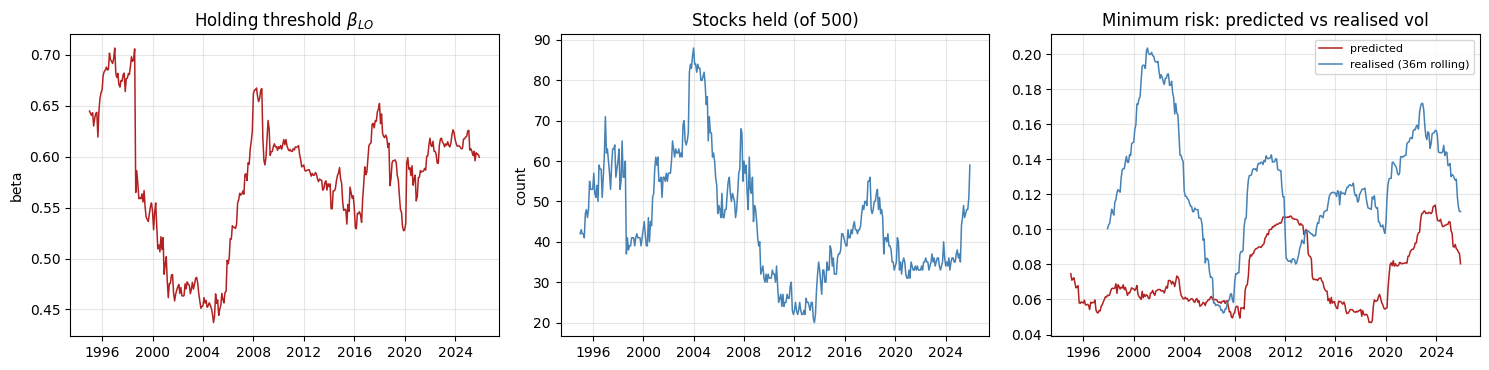

beta_LO    : mean 0.578, range [0.437, 0.707]
stocks held: mean 45, range [20, 88]
ex-ante beta: mean 0.427


In [20]:
mr_panel = panel.xs("min_risk", level="strategy")
mr_periods = pd.PeriodIndex([str(d) for d in mr_panel.index], freq="M").to_timestamp()
roll = mr_panel.exret.rolling(36).std() * np.sqrt(12)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(mr_periods, mr_panel.beta_LO, color="firebrick", lw=1.1)
ax[0].set_title("Holding threshold $\\beta_{LO}$"); ax[0].set_ylabel("beta")

ax[1].plot(mr_periods, mr_panel.n_held, color="steelblue", lw=1.1)
ax[1].set_title(f"Stocks held (of {N})"); ax[1].set_ylabel("count")

ax[2].plot(mr_periods, mr_panel.pred_vol * np.sqrt(12), label="predicted", color="firebrick", lw=1.1)
ax[2].plot(mr_periods, roll, label="realised (36m rolling)", color="steelblue", lw=1.1)
ax[2].set_title("Minimum risk: predicted vs realised vol"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"beta_LO    : mean {mr_panel.beta_LO.mean():.3f}, "
      f"range [{mr_panel.beta_LO.min():.3f}, {mr_panel.beta_LO.max():.3f}]")
print(f"stocks held: mean {mr_panel.n_held.mean():.0f}, "
      f"range [{mr_panel.n_held.min()}, {mr_panel.n_held.max()}]")
print(f"ex-ante beta: mean {mr_panel.exante_beta.mean():.3f}")

## Summary

* Minimum risk delivers the **lowest realised volatility** of the three, by a wide margin,
  which is what it is built to do.
* It gets there by holding roughly **45 of 500 stocks** at an average beta near **0.43** —
  under a single-factor covariance, "minimum risk" is structurally a low-beta bet, exactly
  as the analytic solution says.
* Its **Sharpe ratio does not beat** the cap- or equally weighted benchmarks over the full
  sample, so the volatility reduction came with a return cost.
* The covariance model **underestimates minimum risk's volatility by a factor of roughly
  two**, while pricing the broad benchmarks almost exactly. This is the uncorrelated-
  residual assumption failing where the portfolio is most concentrated, and it is the
  strongest argument in this notebook for either a richer covariance model or a position
  limit.

### Not covered here

Maximum diversification, risk parity and HRP; alternative covariance estimators; position
caps, transaction costs and factor attribution.